# Final Project: Topic Modeling
## Executive Summary: 
In 180 to 200 words, provide an overview of the notebooks you developed. Describe the use case, data, preprocessing steps, model development, and main points of the analysis. State which model works best or that none of the models were satisfactory and provide reasons. Describe the topics and explain how the model will address the use case, or if none of the models worked well, state what the next steps should be.
## Importing the Dataset: Trip Advisor Reviews


In [61]:
import pandas as pd # data manipulation
import langdetect  # language detection
import matplotlib.pyplot  # plotting
import nltk  # natural language processing
import numpy  # arrays and matrices
import pandas  # dataframes
import pyLDAvis  # plotting
import regex  # regular expressions
import sklearn  # machine learning
import unicodedata  # unicode data manipulation
import random # random number generation

# Text preprocessing and feature extraction
from sklearn.decomposition import NMF  # NMF model
from sklearn.decomposition import LatentDirichletAllocation  # LDA model
from sklearn.feature_extraction.text import TfidfVectorizer # TF-IDF vectorizer
from nltk.stem import WordNetLemmatizer  # lemmatizer
from sklearn.feature_extraction.text import CountVectorizer  # Count vectorizer

# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\danie\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\danie\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\danie\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [62]:
url = "https://raw.githubusercontent.com/Hunteracademic/Unsupervised_assignment_1/master/tripadvisor_hotel_reviews.csv"
df = pd.read_csv(url)
df.head()

c:\Users\danie\anaconda3\envs\uml_37\lib\site-packages\pandas\core\frame.py:655: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(IPython.__version__) < LooseVersion('3.0'):
c:\Users\danie\anaconda3\envs\uml_37\lib\site-packages\pandas\core\frame.py:655: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(IPython.__version__) < LooseVersion('3.0'):


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


## Preprocessing: 
Clean and prepare text for LDA and NMF topic modeling. Include steps such as case normalization, lemmatization, stop word removal, and tokenization. 

### Language Filter

In [63]:
def do_language_identifying(txt):
    try: the_language = langdetect.detect(txt)
    except: the_language = 'none'
    return the_language

df['Language'] = df['Review'].apply(do_language_identifying)
df['Language'].value_counts()

en    20478
fr        6
af        4
ca        1
ro        1
es        1
Name: Language, dtype: int64

Removing non-english reviews

In [64]:
reviews_en = df[df['Language'] == 'en']

### Tokenization / Removing Punctuation / Case Normalization

In [65]:
WORD_RE = regex.compile(r"(?V1)\p{L}+(?:[’'-]\p{L}+)*")

def tokenize_for_topics(text):
    text = unicodedata.normalize("NFKC", str(text)).lower()
    text = regex.sub(r"[‘’`´]", "'", text)      # normalize apostrophes
    text = regex.sub(r"[‐‑‒–—−]", "-", text)    # normalize dash variants
    return WORD_RE.findall(text)

reviews_en["Tokens"] = reviews_en["Review"].apply(tokenize_for_topics)

reviews_en['Tokens'][0]

c:\Users\danie\anaconda3\envs\uml_37\lib\site-packages\ipykernel_launcher.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  if __name__ == "__main__":


['nice',
 'hotel',
 'expensive',
 'parking',
 'got',
 'good',
 'deal',
 'stay',
 'hotel',
 'anniversary',
 'arrived',
 'late',
 'evening',
 'took',
 'advice',
 'previous',
 'reviews',
 'did',
 'valet',
 'parking',
 'check',
 'quick',
 'easy',
 'little',
 'disappointed',
 'non-existent',
 'view',
 'room',
 'room',
 'clean',
 'nice',
 'size',
 'bed',
 'comfortable',
 'woke',
 'stiff',
 'neck',
 'high',
 'pillows',
 'not',
 'soundproof',
 'like',
 'heard',
 'music',
 'room',
 'night',
 'morning',
 'loud',
 'bangs',
 'doors',
 'opening',
 'closing',
 'hear',
 'people',
 'talking',
 'hallway',
 'maybe',
 'just',
 'noisy',
 'neighbors',
 'aveda',
 'bath',
 'products',
 'nice',
 'did',
 'not',
 'goldfish',
 'stay',
 'nice',
 'touch',
 'taken',
 'advantage',
 'staying',
 'longer',
 'location',
 'great',
 'walking',
 'distance',
 'shopping',
 'overall',
 'nice',
 'experience',
 'having',
 'pay',
 'parking',
 'night']

### Removing Stop Words

In [66]:
list_stop_words = nltk.corpus.stopwords.words("English")
reviews_en['Tokens'] = reviews_en['Tokens'].apply(lambda tokens: [token for token in tokens if token not in list_stop_words])

c:\Users\danie\anaconda3\envs\uml_37\lib\site-packages\ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  


### Lemmatization

In [67]:
lemmatizer = WordNetLemmatizer()
reviews_en['Tokens'] = reviews_en['Tokens'].apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])

c:\Users\danie\anaconda3\envs\uml_37\lib\site-packages\ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  


In [68]:
reviews_en['Tokens'].head()

0    [nice, hotel, expensive, parking, got, good, d...
1    [ok, nothing, special, charge, diamond, member...
2    [nice, room, experience, hotel, monaco, seattl...
3    [unique, great, stay, wonderful, time, hotel, ...
4    [great, stay, great, stay, went, seahawk, game...
Name: Tokens, dtype: object

Models: Develop code to first vectorize your text data, and then train at least six LDA and six NMF topic models on these vectors. Use clear section headings for each type of model. Record each set of hyperparameters (for both vectorization and the topic models) that you try, and find the perplexity, word-topic table, and document-topic table for each model. Present this information neatly and use it to select your best LDA and NMF models.

### Vectorizing the text data: LDA

In [69]:
LDA_data = reviews_en.copy()
LDA_data['clean_text'] = LDA_data['Tokens'].apply(lambda tokens: ' '.join(tokens))
LDA_data[['Tokens', 'clean_text']].head()

c:\Users\danie\anaconda3\envs\uml_37\lib\site-packages\pandas\core\frame.py:655: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(IPython.__version__) < LooseVersion('3.0'):
c:\Users\danie\anaconda3\envs\uml_37\lib\site-packages\pandas\core\frame.py:655: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(IPython.__version__) < LooseVersion('3.0'):


,Tokens,clean_text
0,"[nice, hotel, expensive, parking, got, good, d...",nice hotel expensive parking got good deal sta...
1,"[ok, nothing, special, charge, diamond, member...",ok nothing special charge diamond member hilto...
2,"[nice, room, experience, hotel, monaco, seattl...",nice room experience hotel monaco seattle good...
3,"[unique, great, stay, wonderful, time, hotel, ...",unique great stay wonderful time hotel monaco ...
4,"[great, stay, great, stay, went, seahawk, game...",great stay great stay went seahawk game awesom...


## Models: 
Develop code to first vectorize your text data, and then train at least six LDA and six NMF topic models on these vectors. Use clear section headings for each type of model. Record each set of hyperparameters (for both vectorization and the topic models) that you try, and find the perplexity, word-topic table, and document-topic table for each model. Present this information neatly and use it to select your best LDA and NMF models.

### Defined Approach:
- Performing grid search on different parameters for the vectorizers in order to select the best combination of parameters + an optimal number of topics.
- Once we select our best combination for the vectorizer, we will explore parameter combinations for the models in order to obtain the best combination and select the best model based on that.

## LDA Exploring

### Selecting our number of topics: Helper Function
Function to explore different number of topics

In [69]:
def perplexity_by_ntopic(data, ntopics, max_df, min_df, max_features):
    """
    Calculate perplexity for different numbers of topics.
    Parameters:
    - data: Document-term matrix (e.g., from CountVectorizer)
    - ntopics: List of numbers of topics to evaluate
    - max_df: Maximum document frequency for term filtering
    - min_df: Minimum document frequency for term filtering
    - max_features: Maximum number of features for term filtering
    Returns:
    - output_df: DataFrame with number of topics and corresponding perplexity scores"""
    
    output_dict = {
        "Number Of Topics": [], 
        "Perplexity Score": []
    }
    
    for t in ntopics:
        lda = sklearn.decomposition.LatentDirichletAllocation(
            n_components=t,
            learning_method="batch",
            random_state=0,
            n_jobs=-1
        )
        lda.fit(data)
        
        output_dict["Number Of Topics"].append(t)
        output_dict["Perplexity Score"].append(lda.perplexity(data))
        print(f"max_df = {max_df}, min_df = {min_df}, max_features = {max_features} : Calculated perplexity for {t} topics: {output_dict['Perplexity Score'][-1]}")
        
    output_df = pandas.DataFrame(output_dict)
    
    index_min_perplexity = output_df["Perplexity Score"].idxmin()
    output_num_topics = output_df.loc[
        index_min_perplexity,  # index
        "Number Of Topics"  # column
    ]
        
    return (output_df, output_num_topics)

### Count Vectorizer Grid Search
According to our research and the examples available in the book, we found that the best word vectorizer for LDA models was `CountVectorizer()`. In this step, we explore different values for a count vectorizer to be used for LDA based on perplexity scores as a starting point for our next exploration.

In [70]:
number_features = 2000 # maximum number of features for CountVectorizer
number_docs = 10 # number of documents to use
number_words = 10

max_dfs = [0.85]
min_dfs = [2, 5, 10]
max_feats = [2000]
hotel_stop_words = ['hotel', 'room', 'stay', 'really', 'just', 'got', 'went', 'also', 'said', 'told', 'day', 'night', 'time', 'week', 'year',    'place', 'thing', 'way', 'bit', 'lot', 'little', 'came', 'come', 'went', 'going', 'went', 'away', 'check', 'booked', 'booking', 'trip', 'visit', 'stayed', 'rooms', 'hotels', 'stays']

# Create a list of CountVectorizer instances with different parameter combinations
count_vectorizers = []
for max_df in max_dfs:
    for min_df in min_dfs:
        for max_features in max_feats:
            vectorizer = CountVectorizer(
                max_df=max_df,
                min_df=min_df,
                max_features=max_features,
                stop_words=hotel_stop_words
            )
            count_vectorizers.append(vectorizer)

In [71]:
# Calculate perplexity for each CountVectorizer and store results in a list of DataFrames
perplexity_dfs = []
for cv in count_vectorizers:
    dtm_cv = cv.fit_transform(LDA_data['clean_text'])
    # Exploring Perplexity for LDA
    lda_perplexity, optimal_num_topics = perplexity_by_ntopic(
    dtm_cv,
    [3, 4, 5, 6],
    cv.max_df,
    cv.min_df,
    cv.max_features
    )

    lda_perplexity['Max_Features'] = cv.max_features
    lda_perplexity['Max_DF'] = cv.max_df
    lda_perplexity['Min_DF'] = cv.min_df
    perplexity_dfs.append(lda_perplexity)

max_df = 0.85, min_df = 2, max_features = 2000 : Calculated perplexity for 3 topics: 894.5011448451688
max_df = 0.85, min_df = 2, max_features = 2000 : Calculated perplexity for 4 topics: 891.0171243262505
max_df = 0.85, min_df = 2, max_features = 2000 : Calculated perplexity for 5 topics: 895.5221526141962
max_df = 0.85, min_df = 2, max_features = 2000 : Calculated perplexity for 6 topics: 887.8944371874238
max_df = 0.85, min_df = 5, max_features = 2000 : Calculated perplexity for 3 topics: 897.7782871400968
max_df = 0.85, min_df = 5, max_features = 2000 : Calculated perplexity for 4 topics: 891.8435707857369
max_df = 0.85, min_df = 5, max_features = 2000 : Calculated perplexity for 5 topics: 890.6384405981818
max_df = 0.85, min_df = 5, max_features = 2000 : Calculated perplexity for 6 topics: 892.7632609275099
max_df = 0.85, min_df = 10, max_features = 2000 : Calculated perplexity for 3 topics: 895.3170266140514
max_df = 0.85, min_df = 10, max_features = 2000 : Calculated perplexity 

In [72]:
perp_concat = pd.concat(perplexity_dfs, ignore_index=True)
perp_concat.sort_values(by='Perplexity Score', inplace=True)
perp_concat.head(10)

,Number Of Topics,Perplexity Score,Max_Features,Max_DF,Min_DF
11,6,886.469085,2000,0.85,10
9,4,887.710496,2000,0.85,10
3,6,887.894437,2000,0.85,2
10,5,888.899125,2000,0.85,10
6,5,890.638441,2000,0.85,5
1,4,891.017124,2000,0.85,2
5,4,891.843571,2000,0.85,5
7,6,892.763261,2000,0.85,5
0,3,894.501145,2000,0.85,2
8,3,895.317027,2000,0.85,10


### LDA Parameters Grid Search
We defined the best parameters combination for the count vectorizer definition based on the results above as `cv_final`. This vectorizer is then used to explore different LDA model options.
We are going to store each model using the `max_iter` parameter as the key and the values as the models themselves.

In [82]:
cv_final = CountVectorizer(
    max_df=0.85,        
    min_df=10,          
    max_features=2000,
    ngram_range=(1, 2)
)
 
dtm_cv_final = cv_final.fit_transform(LDA_data['clean_text'])
 
max_iter = [10, 20, 30]
selected_num_topics = [4, 5, 6]
lda_models_arr = {} # Initialize an empty dictionary to store LDA models with max_iter and num_topics as keys

for iter in max_iter:
    for num_topics in selected_num_topics:
        lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=0, max_iter=iter, n_jobs=-1)
        lda_model.fit(dtm_cv_final)
        lda_models_arr[(iter, num_topics)] = lda_model
        print(f"Max Iterations: {iter} - Number of Topics: {num_topics} - Perplexity: {lda_model.perplexity(dtm_cv_final)}")

Max Iterations: 10 - Number of Topics: 4 - Perplexity: 794.9099830129421
Max Iterations: 10 - Number of Topics: 5 - Perplexity: 791.1576617842763
Max Iterations: 10 - Number of Topics: 6 - Perplexity: 787.4487177906865
Max Iterations: 20 - Number of Topics: 4 - Perplexity: 792.9903034437905
Max Iterations: 20 - Number of Topics: 5 - Perplexity: 788.7253376128565
Max Iterations: 20 - Number of Topics: 6 - Perplexity: 783.5273514576551
Max Iterations: 30 - Number of Topics: 4 - Perplexity: 792.6970915205867
Max Iterations: 30 - Number of Topics: 5 - Perplexity: 788.1002845357322
Max Iterations: 30 - Number of Topics: 6 - Perplexity: 782.6036797478396


### Interpretability Check: Words and Document Matrices of models

In [40]:
def get_topics(mod, vec, names, docs, ndocs, nwords):
    # word to topic matrix
    W = mod.components_
    W_norm = W / W.sum(axis=1)[:, numpy.newaxis]
    # topic to document matrix
    H = mod.transform(vec)
    
    W_dict = {}
    H_dict = {}
    
    for tpc_idx, tpc_val in enumerate(W_norm):
        topic = "Topic{}".format(tpc_idx)
        
        # formatting w
        W_indices = tpc_val.argsort()[::-1][:nwords]
        W_names_values = [
            (round(tpc_val[j], 4), names[j]) 
            for j in W_indices
        ]
        W_dict[topic] = W_names_values
        
        # formatting h
        H_indices = H[:, tpc_idx].argsort()[::-1][:ndocs]
        H_names_values = [
            (round(H[:, tpc_idx][j], 4), docs[j]) 
            for j in H_indices
        ]
        H_dict[topic] = H_names_values
        
    W_df = pd.DataFrame(
        W_dict, 
        index=["Word" + str(i) for i in range(nwords)]
    )
    H_df = pd.DataFrame(
        H_dict,
        index=["Doc" + str(i) for i in range(ndocs)]
    )
        
    return (W_df, H_df)

## Discussion: 
For the best LDA and NMF models, present again the perplexity for each, and display the word-topic and document-topic tables. For your best LDA model, create a biplot visualization using the pyLDAvis package and a t-SNE visualization to explore document-topic relationships in lower-dimensional space. Experiment with values of the relevance metric and be prepared to demonstrate this to your instructor. Write a clear description, in your own words, of the abstract topics found by each model and present this information neatly. Discuss which model has done the best job of identifying topics for your use case and justify this by referring to the analysis and visualizations.
### LDA Visualizations: Biplot

In [71]:
W_df, H_df = get_topics(
    mod=final_lda_bi,
    vec=dtm_bi,
    names=bi_cv.get_feature_names_out(),
    docs=df['Review'].tolist(),
    ndocs=10, 
    nwords=10
)
print('*' * 50)
print("Word - Topic Table:")
print('*' * 50)
print(W_df)

print('*' * 50)
print("Document - Topic Table:")
print('*' * 50)
print(H_df)

**************************************************
Word - Topic Table:
**************************************************
                          Topic0                      Topic1  \
Word0       (0.0254, punta cana)    (0.0267, great location)   
Word1          (0.01, food good)          (0.0161, new york)   
Word2       (0.0078, pool beach)    (0.0146, staff friendly)   
Word3         (0.0076, la carte)    (0.0125, location great)   
Word4       (0.0073, beach pool)     (0.0124, san francisco)   
Word5        (0.0072, make sure)  (0.0118, friendly helpful)   
Word6         (0.0061, pool bar)  (0.0098, highly recommend)   
Word7  (0.0059, beach beautiful)  (0.0094, walking distance)   
Word8     (0.005, speak english)       (0.0084, great staff)   
Word9    (0.005, staff friendly)       (0.0084, great great)   

                           Topic2                      Topic3  
Word0          (0.0278, san juan)       (0.0179, minute walk)  
Word1       (0.0143, new orleans)    (0.0136,

In [91]:
import pyLDAvis
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.manifold import TSNE  # Required for t-SNE projection

# --- Data Preparation ---
neg_neutral = reviews_en[reviews_en['Rating'] <= 3]
positive = reviews_en[reviews_en['Rating'] > 3]
positive_sampled = positive.sample(n=len(neg_neutral), random_state=42)
balanced_df = pd.concat([neg_neutral, positive_sampled]).reset_index(drop=True)
balanced_df['clean_text'] = balanced_df['Tokens'].apply(lambda tokens: ' '.join(tokens))

# --- Vectorization & Modeling (Bi-grams, K=4) ---
bi_cv = CountVectorizer(max_df=0.85, min_df=5, max_features=2000, stop_words=hotel_stop_words, ngram_range=(2, 2))
dtm_bi = bi_cv.fit_transform(balanced_df['clean_text'])

final_lda_bi = LatentDirichletAllocation(n_components=4, random_state=42, n_jobs=1)
final_lda_bi.fit(dtm_bi)

# --- Manual Data Extraction for Visualizer ---
def format_data_for_vis(model, dtm, vectorizer):
    return {
        'topic_term_dists': model.components_ / model.components_.sum(axis=1)[:, np.newaxis],
        'doc_topic_dists': model.transform(dtm),
        'doc_lengths': dtm.sum(axis=1).getA1(),
        'vocab': vectorizer.get_feature_names_out(),
        'term_frequency': dtm.sum(axis=0).getA1()
    }

data = format_data_for_vis(final_lda_bi, dtm_bi, bi_cv)

# --- Visualization with t-SNE ---
# We define a lambda to ensure pyLDAvis uses the sklearn TSNE implementation properly
lda_display = pyLDAvis.prepare(
    **data, 
    sort_topics=False,
    n_jobs=1,
    mds=lambda dists: TSNE(n_components=2, perplexity=2, random_state=42, init='pca').fit_transform(dists)
)

pyLDAvis.display(lda_display)

In [73]:
lda_bi_topic_results = final_lda_bi.transform(dtm_bi)

# Assign the winning topic index to the dataframe
LDA_data['Topic'] = lda_bi_topic_results.argmax(axis=1)
 
# Reorder columns and fix the naming to match your notebook's case-sensitivity
LDA_data = LDA_data[['Review', 'Rating', 'Topic', 'Tokens']]
 
# Preview results
# See the average rating for each topic
print(LDA_data.groupby('Topic')['Rating'].mean())
 
# See how many reviews fell into each topic
print(LDA_data['Topic'].value_counts())

Topic
0    3.688521
1    4.337449
2    3.253386
3    4.111072
Name: Rating, dtype: float64
3    8427
1    4860
0    4164
2    3027
Name: Topic, dtype: int64


### LDA Visualizations: T-SNE

In [76]:
# define functiont to fit and plot t-SNE model

def plot_tsne(data, threshold, perplexity=30, n_iter=1000):
    # filter data according to threshold
    index_meet_threshold = numpy.amax(data, axis=1) >= threshold
    lda_transform_filt = data[index_meet_threshold]
    
    # fit tsne model
    # x-d -> 2-d, x = number of topics
    tsne = sklearn.manifold.TSNE(
        n_components=2, 
        verbose=0, 
        random_state=0, 
        angle=0.5, 
        init='pca',
        perplexity=perplexity,
        n_iter=n_iter
    )
    tsne_fit = tsne.fit_transform(lda_transform_filt)
    
    # most probable topic for each headline
    most_prob_topic = []
    for i in range(tsne_fit.shape[0]):
        most_prob_topic.append(lda_transform_filt[i].argmax())
    
    print("LENGTH:\n{}\n".format(len(most_prob_topic)))

    unique, counts = numpy.unique(
        numpy.array(most_prob_topic), 
        return_counts=True
    )

    print("COUNTS:\n{}\n".format(numpy.asarray((unique, counts)).T))
    
    # make plot
    color_list = ['b', 'g', 'r', 'c', 'm', 'y', 'k']

    for i in list(set(most_prob_topic)):
        indices = [idx for idx, val in enumerate(most_prob_topic) if val == i]
        matplotlib.pyplot.scatter(
            x=tsne_fit[indices, 0], 
            y=tsne_fit[indices, 1], 
            s=0.5, 
            c=color_list[i], 
            label='Topic' + str(i),
            alpha=0.25
        )

    matplotlib.pyplot.xlabel('x-tsne')
    matplotlib.pyplot.ylabel('y-tsne')
    matplotlib.pyplot.legend(markerscale=10)

LENGTH:
10958

COUNTS:
[[   0 2788]
 [   1 2062]
 [   2 1071]
 [   3 5037]]



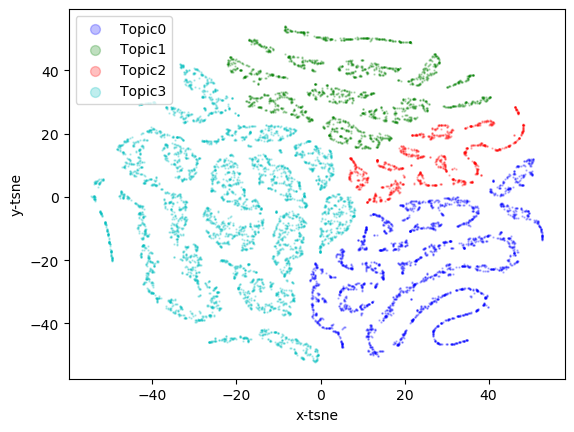

In [92]:
plot_tsne(data=lda_bi_topic_results, threshold=0.75, perplexity=15, n_iter=500)

### Vectorization for NMF
### Hyperparameter Stack:
.....

In [84]:
# Create a dedicated NMF dataframe from your english reviews
nmf_data = reviews_en.copy()

# Ensure the clean_text column exists (joining the lemmatized tokens)
nmf_data['clean_text'] = nmf_data['Tokens'].apply(lambda tokens: ' '.join(tokens))

# Preview the clean data
nmf_data[['Review', 'clean_text']].head()

c:\Users\danie\anaconda3\envs\uml_37\lib\site-packages\pandas\core\frame.py:655: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(IPython.__version__) < LooseVersion('3.0'):
c:\Users\danie\anaconda3\envs\uml_37\lib\site-packages\pandas\core\frame.py:655: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(IPython.__version__) < LooseVersion('3.0'):


,Review,clean_text
0,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,nice room experience hotel monaco seattle good...
3,"unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...
4,"great stay great stay, went seahawk game aweso...",great stay great stay went seahawk game awesom...


In [85]:
def nmf_reconstruction_error(data, ntopics, max_df, min_df, max_features):  # function to calculate reconstruction error for NMF model with different numbers of topics and vectorizer parameters
    nmf_output_dict = {
        "Number Of Topics": [], 
        "Reconstruction Error": []
    }
    
    for t in ntopics:   # iterate over the list of topic numbers
        nmf = sklearn.decomposition.NMF(
            n_components=t,
            solver='cd',
            random_state=0
        )
        nmf.fit(data)
        
        nmf_output_dict["Number Of Topics"].append(t)
        nmf_output_dict["Reconstruction Error"].append(nmf.reconstruction_err_)
        print(f"max_df = {max_df}, min_df = {min_df}, max_features = {max_features} : Calculated reconstruction error for {t} topics: {nmf_output_dict['Reconstruction Error'][-1]}")
        
    output_df = pandas.DataFrame(nmf_output_dict)   # convert the output dictionary to a pandas dataframe for easier analysis
    
    index_min_perplexity = output_df["Reconstruction Error"].idxmin()   # get the index of the minimum reconstruction error
    output_num_topics = output_df.loc[
        index_min_perplexity,
        "Number Of Topics"
    ]
        
    return (output_df, output_num_topics)

In [86]:
tfidf_number_features = 2000
tfidf_number_docs = 10
tfidf_number_words = 10

tfidf_max_dfs = [0.85]
tfidf_min_dfs = [2, 5, 10]
tfidf_max_feats = [2000]

tfidf_vectorizers = [] 
for max_df in tfidf_max_dfs:
    for min_df in tfidf_min_dfs:
        for max_features in tfidf_max_feats:
            tfidf_vectorizer = TfidfVectorizer(
                max_df=max_df,
                min_df=min_df,
                max_features=max_features,
                stop_words=hotel_stop_words,
                ngram_range=(2, 2)
            )
            tfidf_vectorizers.append(tfidf_vectorizer)

In [87]:
import warnings
warnings.filterwarnings("ignore")
tfidf_perplexity_dfs = []
for tfidf_v in tfidf_vectorizers:
    dtm_cv = tfidf_v.fit_transform(nmf_data['clean_text'])

    nmf_perplexity, optimal_num_topics = nmf_reconstruction_error(
        dtm_cv,
        [3, 4, 5, 6],
        tfidf_v.max_df,
        tfidf_v.min_df,
        tfidf_v.max_features
    )

    nmf_perplexity['Max_Features'] = tfidf_v.max_features
    nmf_perplexity['Max_DF'] = tfidf_v.max_df
    nmf_perplexity['Min_DF'] = tfidf_v.min_df
    tfidf_perplexity_dfs.append(nmf_perplexity)

max_df = 0.85, min_df = 2, max_features = 2000 : Calculated reconstruction error for 3 topics: 140.82748524244042
max_df = 0.85, min_df = 2, max_features = 2000 : Calculated reconstruction error for 4 topics: 140.49359920825293
max_df = 0.85, min_df = 2, max_features = 2000 : Calculated reconstruction error for 5 topics: 140.18162950745776
max_df = 0.85, min_df = 2, max_features = 2000 : Calculated reconstruction error for 6 topics: 139.93354651069114
max_df = 0.85, min_df = 5, max_features = 2000 : Calculated reconstruction error for 3 topics: 140.83084947116873
max_df = 0.85, min_df = 5, max_features = 2000 : Calculated reconstruction error for 4 topics: 140.49712508654144
max_df = 0.85, min_df = 5, max_features = 2000 : Calculated reconstruction error for 5 topics: 140.18523428532532
max_df = 0.85, min_df = 5, max_features = 2000 : Calculated reconstruction error for 6 topics: 139.93666441016484
max_df = 0.85, min_df = 10, max_features = 2000 : Calculated reconstruction error for 3 

LENGTH:
544

COUNTS:
[[  1 145]
 [  2 275]
 [  3 124]]



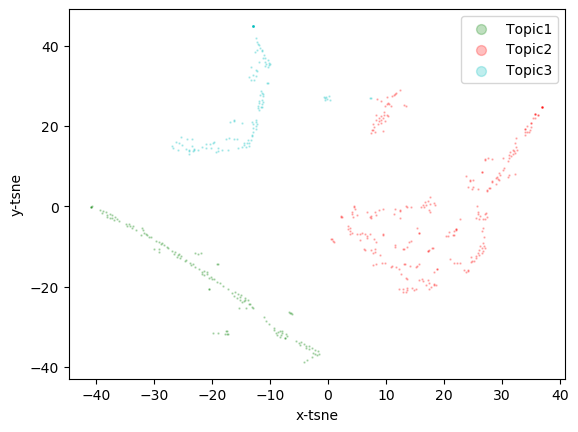

In [90]:

nmf = sklearn.decomposition.NMF(
    n_components=4,
    solver='cd',
    random_state=0,
)

nmf_transformed = nmf.fit_transform(tfidf_vectorizers[1].fit_transform(nmf_data['clean_text']))

plot_tsne(data=nmf_transformed, threshold=0.10, perplexity=15, n_iter=500)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF

nmf_transformed = []

for i in range(len(tfidf_vectorizers)):
    print(f"--- Visualizing Model {i+1} ---")
    
    # 1. Vectorize text with the current vectorizer in your list
    current_dtm = tfidf_vectorizers[i].fit_transform(nmf_data['clean_text'])
    
    # 2. Instantiate and Fit a fresh NMF model for this specific vectorizer
    nmf_model = NMF(n_components=4, solver='cd', random_state=0)
    weights = nmf_model.fit_transform(current_dtm)
    
    # 3. Save the results to your list
    nmf_transformed.append(weights)
    
    # 4. Generate the plot
    # If plot_tsne doesn't call plt.show(), we call it here
    plot_tsne(data=weights, threshold=0)
    
    # 5. Force the plot to render for THIS model before the next iteration starts
    plt.title(f"NMF t-SNE Plot: Model {i+1}")
    plt.show()

--- Visualizing Model 1 ---


KeyboardInterrupt: 

In [ ]:

def get_topics(mod, vec, names, docs, ndocs, nwords):
    # word to topic matrix
    W = mod.components_ # shape: (n_topics, n_words)
    W_norm = W / W.sum(axis=1)[:, numpy.newaxis]    # normalize rows to sum to 1
    # topic to document matrix
    H = mod.transform(vec)  # shape: (n_docs, n_topics)
    
    W_dict = {}
    H_dict = {}
    
    for tpc_idx, tpc_val in enumerate(W_norm):  # iterate over topics
        topic = "Topic{}".format(tpc_idx)   # create topic name
        
        # formatting w
        W_indices = tpc_val.argsort()[::-1][:nwords]    # get indices of top n words for this topic
        W_names_values = [
            (round(tpc_val[j], 4), names[j]) 
            for j in W_indices
        ]   # create list of tuples (value, word) for top n words
        W_dict[topic] = W_names_values  # assign list of tuples to topic in W_dict
        
        # formatting h
        H_indices = H[:, tpc_idx].argsort()[::-1][:ndocs]   # get indices of top n documents for this topic
        H_names_values = [
            (round(H[:, tpc_idx][j], 4), docs[j])   # create list of tuples (value, document) for top n documents
            for j in H_indices
        ]
        H_dict[topic] = H_names_values  # assign list of tuples to topic in H_dict
        
    W_df = pandas.DataFrame(    # create dataframe from W_dict with word names as index
        W_dict, 
        index=["Word" + str(i) for i in range(nwords)]
    )
    H_df = pandas.DataFrame(    # create dataframe from H_dict with document names as index
        H_dict,
        index=["Doc" + str(i) for i in range(ndocs)]
    )
        
    return (W_df, H_df)

In [ ]:
wdf, hdf, = get_topics(
    mod=nmf, 
    vec=tfidf_vectorizers[0].fit_transform(nmf_data['clean_text']), # fit_transform the clean text data using the first TF-IDF vectorizer
    names=tfidf_vectorizers[0].get_feature_names_out(), 
    docs=nmf_data['Review'].tolist(), 
    ndocs=tfidf_number_docs, 
    nwords=tfidf_number_words
)

In [ ]:
print(wdf)

                             Topic0                      Topic1  \
Word0        (0.0129, mixed review)   (0.0239, quality service)   
Word1       (0.0121, staff helpful)       (0.0137, santa maria)   
Word2          (0.0108, wall paper)         (0.0074, food food)   
Word3            (0.0092, th floor)       (0.0065, making sure)   
Word4          (0.0082, good value)         (0.0064, old world)   
Word5        (0.008, good location)          (0.006, pool good)   
Word6         (0.0072, value price)  (0.0056, language barrier)   
Word7       (0.0061, train station)       (0.0055, beach ocean)   
Word8        (0.0051, nice balcony)    (0.0052, pool beautiful)   
Word9  (0.0049, highly recommended)         (0.0048, beach bar)   

                               Topic2                        Topic3  
Word0        (0.1297, staff friendly)         (0.1731, great loved)  
Word1        (0.1002, friendly great)     (0.0381, location lovely)  
Word2        (0.0134, clean spacious)       (0.0221,

In [ ]:
print(hdf)  

                                                 Topic0  \
Doc0  (0.072, great hotel stayed nights april 08. gr...   
Doc1  (0.0656, good value berlin, stayed hotel octob...   
Doc2  (0.0656, great base seeing bejing stayed hotel...   
Doc3  (0.0646, perfectly situated hotel stayed hotel...   
Doc4  (0.0608, good hotel needing upgrade spent 2 ni...   
Doc5  (0.0599, nice hotel location questionable stay...   
Doc6  (0.0597, great hotel, just returned 3 night st...   
Doc7  (0.0595, lovely hotel, hotel nice hotel, booke...   
Doc8  (0.0591, beautiful great hotel 25 day stay ita...   
Doc9  (0.059, great hotel stayed hotel 41 times squa...   

                                                 Topic1  \
Doc0  (0.1959, talking hurricane, visited secrets ex...   
Doc1  (0.1959, fabulous dreams, loved incredible tri...   
Doc2  (0.1959, vacation paradise, family recently re...   
Doc3  (0.1959, worst vacations thanks resort, n't kn...   
Doc4  (0.1959, beware parasites beware travellers, j...